## Homework 3 : Interpolator

In [ ]:
# Cell 1 — 參數設定
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
import struct
import os
DAT_DIR = r'.\00_TESTED\src'

# Step 1 parameters
d = 9
phi = d % 2                      
mu_values = np.arange(0, 8) / 8   # [0, 1/8, 2/8, ..., 7/8]
m_range = np.arange(10, 21)       # 10 to 20

# Step 2 parameters
m_range2 = np.arange(4, 9)        # m = 4 to 8
alpha = 0.5                       # piecewise parabolic alpha (fixed by 0.5)

### Step 1 (訊號產生 + 內插 + 誤差計算)

In [2]:
# Cell 2 — 訊號產生 + 內插 + 誤差計算

# 訊號查找表 (m = 9..22，支援 m+2 存取, 因為 Second-Order 需要 m+2 的樣本點)
m_all = np.arange(9, 23)

# 定義 X1[m] Function 
x1_lut = np.cos(2*np.pi*(m_all/10 + phi/2)) + 1j*np.sin(2*np.pi*(m_all/10 + phi/2))

# 因為訊號 m 從 9 開始，因此要減 9 才會讓偏移量正確
def x1_at(m): 
    return x1_lut[m - 9]

# Interpolator Function
def linear_interpolator(m, mu):
    return mu * x1_at(m+1) + (1 - mu) * x1_at(m)

def second_order_interpolator(m, mu):
    C0  = (1 - mu) * (2 - mu) / 2
    Cm1 = mu * (2 - mu)
    Cm2 = -mu * (1 - mu) / 2
    return C0 * x1_at(m) + Cm1 * x1_at(m+1) + Cm2 * x1_at(m+2)

# 定義 X1[t] Function 宣告，用來計算真實誤差
def x1_true(t):  # t = m + mu
    return np.cos(2*np.pi*(t/10 + phi/2)) + 1j*np.sin(2*np.pi*(t/10 + phi/2))

# 掃描 88 個 (m, μ) 點
t_pts, lin_out, so_out, true_out = [], [], [], []
for m in m_range:
    for mu in mu_values:
        t = m + mu
        t_pts.append(t)
        lin_out.append(linear_interpolator(m, mu))
        so_out.append(second_order_interpolator(m, mu))
        true_out.append(x1_true(t))

t_pts    = np.array(t_pts)
lin_out  = np.array(lin_out)
so_out   = np.array(so_out)
true_out = np.array(true_out)

# 誤差（複數絕對值)
err_lin = np.abs(true_out - lin_out)
err_so  = np.abs(true_out - so_out)

# 高解析度參考曲線，這樣畫圖才會夠更接近連續曲線
t_fine    = np.linspace(10, 20 + 7/8, 1000)
true_fine = x1_true(t_fine)

### Step 1 (畫圖)

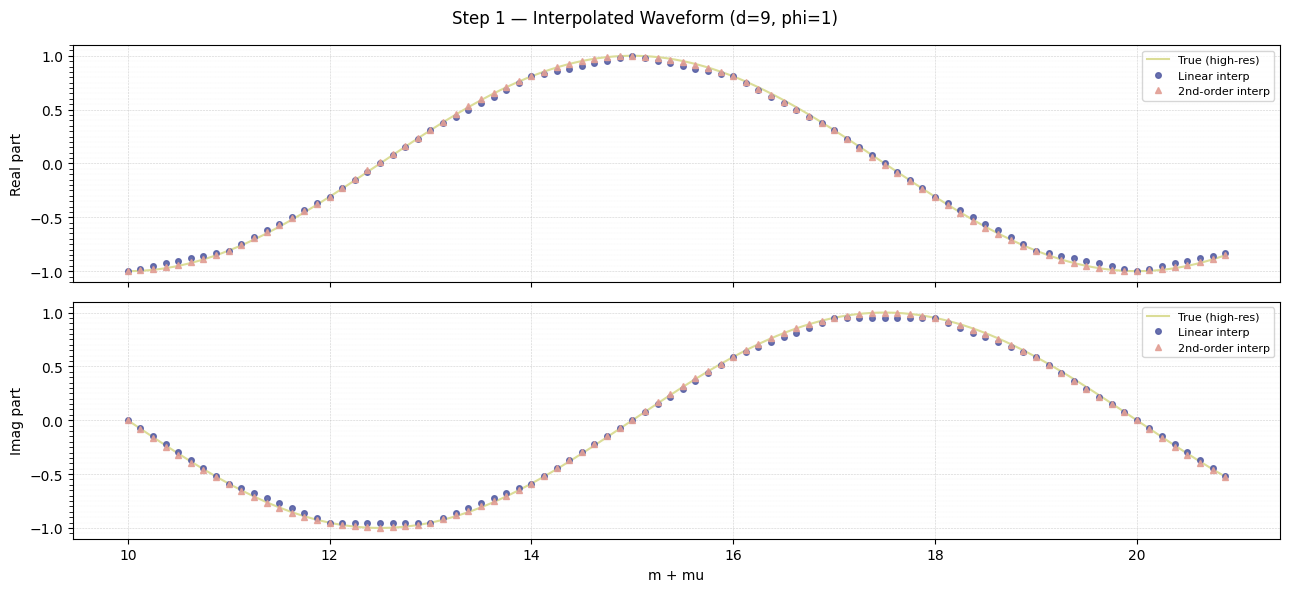

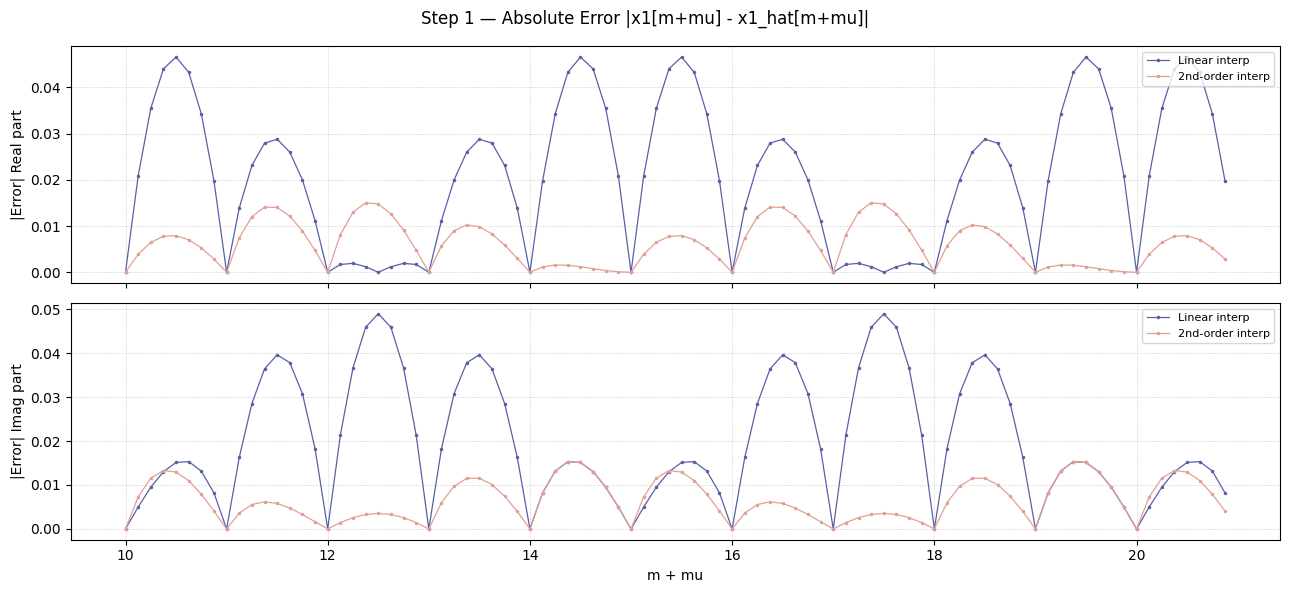

Max |error| Linear   : 4.894348e-02
Max |error| 2nd-order: 1.539266e-02


In [3]:
# Cell 3 - 畫圖

# 配色 (學術風格)
COLOR_TRUE   = "#DBDD97"   # 真實曲線
COLOR_LINEAR = "#5860A5"   # linear
COLOR_SO     = "#E29F95"   # 2nd-order

# 圖 1: 波形 (實部 / 虛部)
fig1, axes1 = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig1.suptitle('Step 1 — Interpolated Waveform (d=9, phi=1)', fontsize=12)

for ax, part, label in zip(axes1, [np.real, np.imag], ['Real part', 'Imag part']):
    ax.plot(t_fine, part(true_fine),
            color=COLOR_TRUE, linewidth=1.5, alpha=1.0, label='True (high-res)')
    ax.plot(t_pts, part(lin_out),
            'o', color=COLOR_LINEAR, markersize=4, alpha=0.9, label='Linear interp')
    ax.plot(t_pts, part(so_out),
            '^', color=COLOR_SO, markersize=4, alpha=0.9, label='2nd-order interp')
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=8)
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
    ax.tick_params(axis='y', which='minor', length=3)
    ax.grid(True, which='major', linewidth=0.4, linestyle='--', alpha=0.6)
    ax.grid(True, which='minor', linewidth=0.2, linestyle=':', alpha=0.4)  # minor grid

axes1[-1].set_xlabel('m + mu')
fig1.tight_layout()
plt.show()

# 圖 2: 絕對誤差 (實部 / 虛部)
fig2, axes2 = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig2.suptitle('Step 1 — Absolute Error |x1[m+mu] - x1_hat[m+mu]|', fontsize=12)

err_lin_real = np.abs(true_out.real - lin_out.real)
err_lin_imag = np.abs(true_out.imag - lin_out.imag)
err_so_real  = np.abs(true_out.real - so_out.real)
err_so_imag  = np.abs(true_out.imag - so_out.imag)

for ax, err_l, err_s, label in zip(
    axes2,
    [err_lin_real, err_lin_imag],
    [err_so_real,  err_so_imag],
    ['|Error| Real part', '|Error| Imag part']
):
    ax.plot(t_pts, err_l, '.-', color=COLOR_LINEAR,
            markersize=3, linewidth=0.9, label='Linear interp')
    ax.plot(t_pts, err_s, '.-', color=COLOR_SO,
            markersize=3, linewidth=0.9, label='2nd-order interp')
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linewidth=0.4, linestyle='--', alpha=0.6)

axes2[-1].set_xlabel('m + mu')
fig2.tight_layout()
plt.show()

print(f'Max |error| Linear   : {err_lin.max():.6e}')
print(f'Max |error| 2nd-order: {err_so.max():.6e}')

### Step 2 (訊號產生 + 內插 + 誤差計算)

In [4]:
# Cell 4 - 訊號 LUT、函式定義、計算插值與誤差

# x2 LUT: 要掃描 m=4 ~ m=8，因此需要涵蓋 m=3 到 m=10（支援 m-1 到 m+2 存取）
m_all2 = np.arange(3, 11)

# 定義 X2 Function
x2_lut = 2**(-20) * (np.cos(2*np.pi*(m_all2/4 + phi/3))
                   + 1j*np.sin(2*np.pi*(m_all2/4 + phi/3)))

# 因為訊號 m 從 3 開始，因此要減 3 才會讓偏移量正確
def x2_at(m):
    return x2_lut[m - 3]

# 定義 X2[t] Function 宣告，用來計算真實誤差
def x2_true(t):   # t = m + mu
    return 2**(-20) * (np.cos(2*np.pi*(t/4 + phi/3))
                     + 1j*np.sin(2*np.pi*(t/4 + phi/3)))


# Interpolator Function
def linear_interpolator2(m, mu):
    return mu * x2_at(m+1) + (1 - mu) * x2_at(m)

def piecewise_parabolic(m, mu, a=0.5):
    Cm1 = -a*mu + a*mu**2
    C0  =  1 + (a-1)*mu - a*mu**2
    C1  =  (a+1)*mu - a*mu**2
    C2  = -a*mu + a*mu**2
    return Cm1*x2_at(m-1) + C0*x2_at(m) + C1*x2_at(m+1) + C2*x2_at(m+2)

# 掃描 40 個 (m, μ) 點
t_pts2, lin_out2, pp_out2, true_out2 = [], [], [], []
for m in m_range2:
    for mu in mu_values:
        t = m + mu
        t_pts2.append(t)
        lin_out2.append(linear_interpolator2(m, mu))
        pp_out2.append(piecewise_parabolic(m, mu, alpha))
        true_out2.append(x2_true(t))

t_pts2    = np.array(t_pts2)
lin_out2  = np.array(lin_out2)
pp_out2   = np.array(pp_out2)
true_out2 = np.array(true_out2)

err_lin2 = np.abs(true_out2 - lin_out2)
err_pp2  = np.abs(true_out2 - pp_out2)

# 高解析度參考曲線
t_fine2    = np.linspace(4, 8 + 7/8, 1000)
true_fine2 = x2_true(t_fine2)

print(f'Max |error| Linear       : {err_lin2.max():.6e}')
print(f'Max |error| PP (a={alpha}): {err_pp2.max():.6e}')

Max |error| Linear       : 2.793247e-07
Max |error| PP (a=0.5): 5.785005e-08


### Step 2 (畫圖)

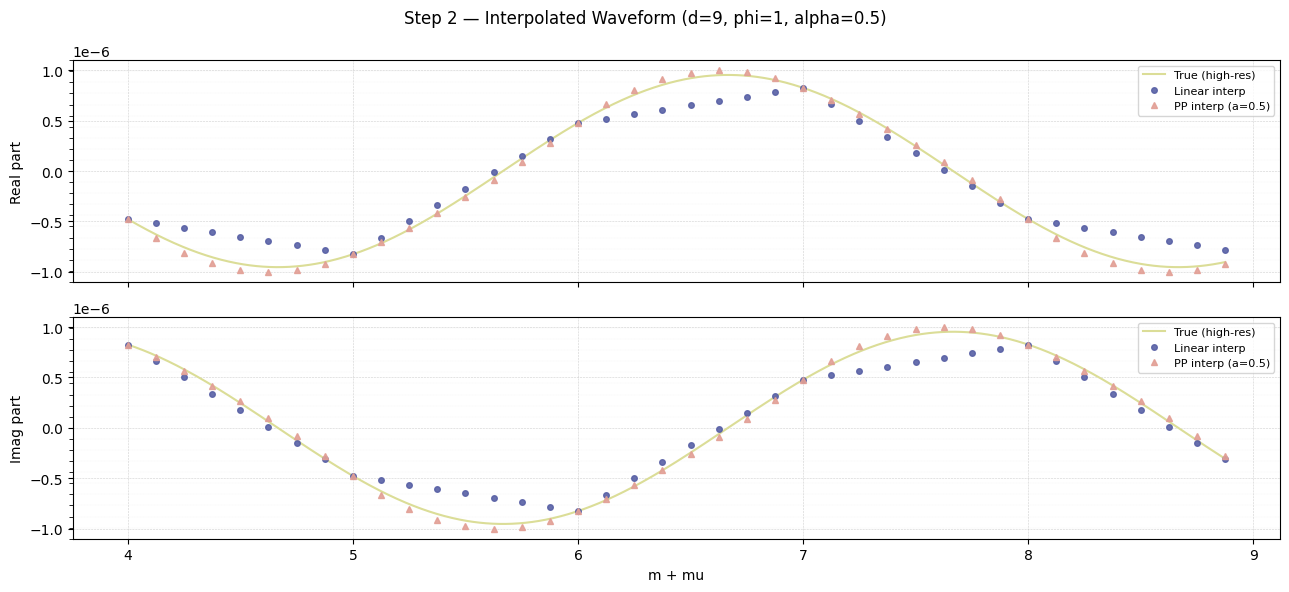

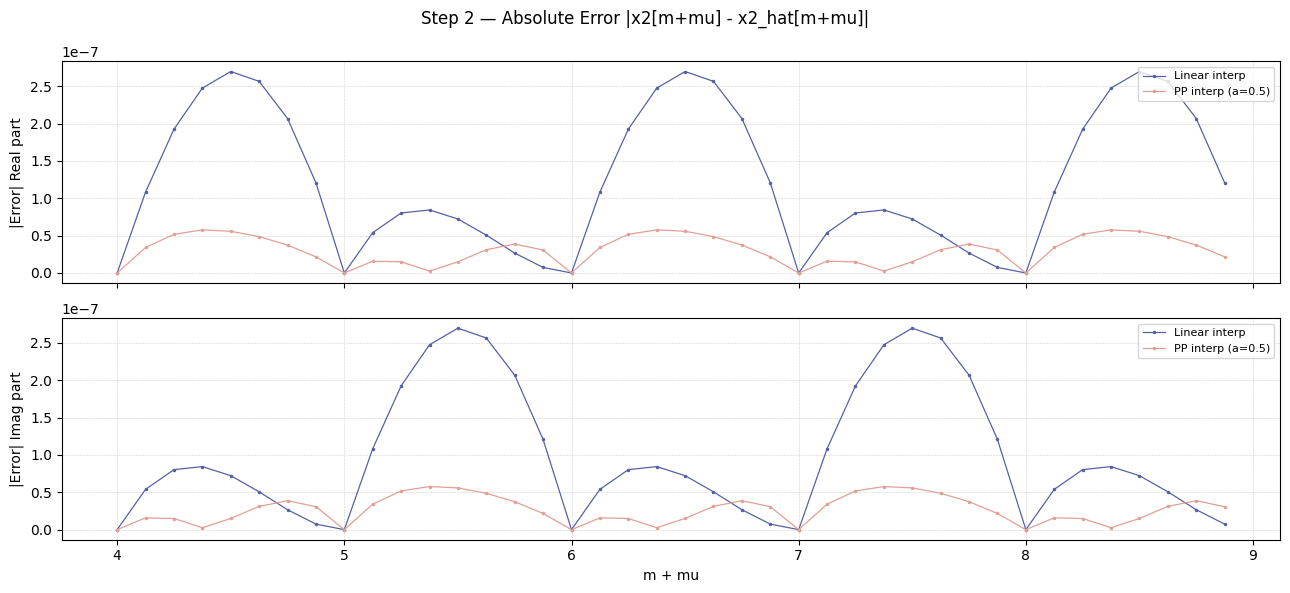

Max |error| Linear       : 2.793247e-07
Max |error| PP (a=0.5): 5.785005e-08


In [5]:
# Cell 5 - Step 2: 畫圖

# 配色 (與 Step 1 相同風格)
COLOR_TRUE   = "#DBDD97"   # 真實曲線
COLOR_LINEAR = "#5860A5"   # linear
COLOR_PP     = "#E29F95"   # piecewise parabolic

# 圖 1: 波形 (實部 / 虛部)
fig1, axes1 = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig1.suptitle('Step 2 — Interpolated Waveform (d=9, phi=1, alpha=0.5)', fontsize=12)

for ax, part, label in zip(axes1, [np.real, np.imag], ['Real part', 'Imag part']):
    ax.plot(t_fine2, part(true_fine2),
            color=COLOR_TRUE, linewidth=1.5, alpha=1.0, label='True (high-res)')
    ax.plot(t_pts2, part(lin_out2),
            'o', color=COLOR_LINEAR, markersize=4, alpha=0.9, label='Linear interp')
    ax.plot(t_pts2, part(pp_out2),
            '^', color=COLOR_PP, markersize=4, alpha=0.9, label='PP interp (a=0.5)')
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=8)
    ax.yaxis.set_minor_locator(plt.MultipleLocator(ax.get_ylim()[1] * 0.1 if ax.get_ylim()[1] != 0 else 0.05))
    ax.tick_params(axis='y', which='minor', length=3)
    ax.grid(True, which='major', linewidth=0.4, linestyle='--', alpha=0.6)
    ax.grid(True, which='minor', linewidth=0.2, linestyle=':', alpha=0.4)

axes1[-1].set_xlabel('m + mu')
fig1.tight_layout()
plt.show()

# 圖 2: 絕對誤差 (實部 / 虛部)
fig2, axes2 = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig2.suptitle('Step 2 — Absolute Error |x2[m+mu] - x2_hat[m+mu]|', fontsize=12)

err_lin2_real = np.abs(true_out2.real - lin_out2.real)
err_lin2_imag = np.abs(true_out2.imag - lin_out2.imag)
err_pp2_real  = np.abs(true_out2.real - pp_out2.real)
err_pp2_imag  = np.abs(true_out2.imag - pp_out2.imag)

for ax, err_l, err_p, label in zip(
    axes2,
    [err_lin2_real, err_lin2_imag],
    [err_pp2_real,  err_pp2_imag],
    ['|Error| Real part', '|Error| Imag part']
):
    ax.plot(t_pts2, err_l, '.-', color=COLOR_LINEAR,
            markersize=3, linewidth=0.9, label='Linear interp')
    ax.plot(t_pts2, err_p, '.-', color=COLOR_PP,
            markersize=3, linewidth=0.9, label='PP interp (a=0.5)')
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linewidth=0.4, linestyle='--', alpha=0.6)

axes2[-1].set_xlabel('m + mu')
fig2.tight_layout()
plt.show()

print(f'Max |error| Linear       : {err_lin2.max():.6e}')
print(f'Max |error| PP (a={alpha}): {err_pp2.max():.6e}')

### Step 3 (BF16 Bit-True Model)

In [6]:
# Cell 6 - BF16 Bit-True Model

# 用 namedtuple 來打包會比用 tuple 簡單一點，用 tuple 就是確保 s, e, f 三個欄位。
BF16 = namedtuple('BF16', ['s', 'e', 'f'])  # s: 0/1, e: 0-255 (biased 指數), f: 0-127

def bf16_from_fields(s, e_bits_str, f_bits_str):
    """把作業給的測資做轉換，轉換成整數"""
    return BF16(s=int(s),
                e=int(e_bits_str.replace('_', ''), 2),
                f=int(f_bits_str.replace('_', ''), 2))

def bf16_to_float(x):
    """將 BF16 轉換為 Python float"""
    if x.e == 0:
        return 0.0
    return ((-1) ** x.s) * (2 ** (x.e - 127)) * (1 + x.f / 128)

def bf16_add(a, b):
    """BF16 加法 (截斷模式)"""
    m1 = (1 << 7) | a.f   # 8-bit significand，加上 implicit bit
    m2 = (1 << 7) | b.f

    # 對齊指數: 較小者右移，移出的位元直接截斷
    if a.e >= b.e:
        m2 >>= (a.e - b.e)
        exp = a.e
    else:
        m1 >>= (b.e - a.e)
        exp = b.e

    # 帶符號相加
    sm = (m1 if a.s == 0 else -m1) + (m2 if b.s == 0 else -m2)
    if sm == 0:
        return BF16(0, 0, 0)

    rs, rm = (0, sm) if sm > 0 else (1, -sm)

    # 正規化: 若溢位 (rm >= 2^8) 則右移一位
    if rm >= (1 << 8):
        rm >>= 1
        exp += 1
    else:
        # 若消去 (rm < 2^7) 則左移直到 implicit bit 回到 bit7
        while rm < (1 << 7) and exp > 1:
            rm <<= 1
            exp -= 1
        if rm < (1 << 7):        # 仍不足最小正規數 -> underflow
            return BF16(0, 0, 0)

    if exp <= 0:
        return BF16(0, 0, 0)     # underflow
    if exp >= 255:
        return BF16(rs, 254, 127)  # 鉗位至最大正規數 (不輸出 inf)

    return BF16(rs, exp, rm & 0x7F)

def bf16_mul(a, b):
    """BF16 乘法 (截斷模式)。"""
    rs = a.s ^ b.s
    m1 = (1 << 7) | a.f
    m2 = (1 << 7) | b.f

    product = m1 * m2                          # 最多 16 bits (255*255=65025)
    actual_exp = (a.e - 127) + (b.e - 127)    # 兩個真實指數相加

    # 正規化: 兩個 1.xxx 相乘結果在 [1.0, 4.0)
    # 若 leading bit 在 bit15 表示結果為 2.xxx -> 右移一位修正
    if product >= (1 << 15):
        product >>= 1
        actual_exp += 1

    result_exp = actual_exp + 127              # 加回 bias

    if result_exp <= 0:
        return BF16(0, 0, 0)     # underflow
    if result_exp >= 255:
        return BF16(rs, 254, 127)

    # 截斷: implicit bit 在 bit14，fraction 取 bit13..7 (共 7 bits)
    result_f = (product >> 7) & 0x7F

    return BF16(rs, result_exp, result_f)

def bf16_display(label, op, result):
    """印出 BF16 結果的十進位與二進位 (S, E, F)。"""
    val = bf16_to_float(result)
    e_str = f'{result.e:08b}'
    f_str = f'{result.f:07b}'
    print(f"{label} ({op}):")
    print(f"  Decimal: {val:.6g}")
    print(f"  Binary : S={result.s}, E={e_str[:4]}_{e_str[4:]}, F={f_str[:4]}_{f_str[4:]}")
    print()

# ── 測試案例 ─────────────────────────────────────────────────────────────────
a1 = bf16_from_fields(1, '10000011', '0000000')
a2 = bf16_from_fields(0, '10001011', '0000011')

b1 = bf16_from_fields(1, '00000001', '0000011')
b2 = bf16_from_fields(0, '00000001', '1111010')

c1 = bf16_from_fields(1, '00000010', '1100000')
c2 = bf16_from_fields(0, '01111100', '0000110')

d1 = bf16_from_fields(0, '01100011', '1011110')
d2 = bf16_from_fields(0, '10010011', '0101000')

bf16_display("(a)", "Addition",       bf16_add(a1, a2))
bf16_display("(b)", "Addition",       bf16_add(b1, b2))
bf16_display("(c)", "Multiplication", bf16_mul(c1, c2))
bf16_display("(d)", "Multiplication", bf16_mul(d1, d2))

# ── 通用 Helper Functions (供 Cell 7 使用) ───────────────────────────────────

def float_to_bf16(f):
    """Python float → BF16 (截斷 float32 低 16 bits)"""
    raw = struct.pack('>f', float(f))
    hi  = (raw[0] << 8) | raw[1]
    s   = (hi >> 15) & 1
    e   = (hi >> 7)  & 0xFF
    fr  = hi & 0x7F
    if e == 0:          # subnormal → 0
        return BF16(0, 0, 0)
    return BF16(s, e, fr)

def bf16_neg(x):
    """BF16 取負 (flip sign bit; zero 保持不變)"""
    if x.e == 0:
        return BF16(0, 0, 0)
    return BF16(1 - x.s, x.e, x.f)

# 因為 0.5 會很常用到，所以先定義 0.5 的 BF16 常數，為 (0, 2^(-1), 0) => (0, 127-1, 0) 
BF16_HALF = BF16(0, 126, 0)

(a) (Addition):
  Decimal: 4192
  Binary : S=0, E=1000_1011, F=0000_011

(b) (Addition):
  Decimal: 0
  Binary : S=0, E=0000_0000, F=0000_000

(c) (Multiplication):
  Decimal: 0
  Binary : S=0, E=0000_0000, F=0000_000

(d) (Multiplication):
  Decimal: 0.0088501
  Binary : S=0, E=0111_1000, F=0010_001



### Step 3 (Architecture Bit-True Model)

In [7]:
# Cell 7 - Second-order Polynomial Interpolator (Farrow structure, hardware-sharing)

def bf16_half(x):
    """BF16 x0.5: exponent-1 (右移 1 位)，不需要乘法器"""
    if x.e <= 1:
        return BF16(0, 0, 0)  # underflow
    return BF16(x.s, x.e - 1, x.f)

def farrow_bf16_component(Xm, Xm1, Xm2, mu_b):
    # 共享節點（黃色三角形，exponent-1，非乘法器）
    half_Xm2 = bf16_half(Xm2)          # 0.5 * X(m+2)
    half_Xm  = bf16_half(Xm)           # 0.5 * X(m)

    # 其餘節點（純加法）
    Xm1_x2 = bf16_add(Xm1, Xm1)       # 2 * X(m+1)
    Xm_1_5 = bf16_add(Xm, half_Xm)    # 1.5 * X(m)

    # v2 = 0.5*X(m+2) - X(m+1) + 0.5*X(m)
    v2 = bf16_add(half_Xm2, bf16_neg(Xm1))
    v2 = bf16_add(v2, half_Xm)

    # v1 = -0.5*X(m+2) + 2*X(m+1) - 1.5*X(m)
    v1 = bf16_add(bf16_neg(half_Xm2), Xm1_x2)
    v1 = bf16_add(v1, bf16_neg(Xm_1_5))

    # v0 = X(m)
    v0 = Xm

    # Horner's method: out = v0 + mu*(v1 + mu*v2)
    inner = bf16_add(v1, bf16_mul(mu_b, v2))
    return bf16_add(v0, bf16_mul(mu_b, inner))

# 保留 BF16 namedtuple，供 .dat 產生使用
arch_real_out      = []
arch_imag_out      = []
arch_real_out_bf16 = []  
arch_imag_out_bf16 = []

# 掃描 88 個點
for m in m_range:         # 10..20
    for mu in mu_values:  # 0, 1/8, ..., 7/8
        mu_b = float_to_bf16(mu)

        # Real datapath
        out_r = farrow_bf16_component(
            float_to_bf16(x1_at(m  ).real),
            float_to_bf16(x1_at(m+1).real),
            float_to_bf16(x1_at(m+2).real),
            mu_b
        )
        # Imag datapath
        out_i = farrow_bf16_component(
            float_to_bf16(x1_at(m  ).imag),
            float_to_bf16(x1_at(m+1).imag),
            float_to_bf16(x1_at(m+2).imag),
            mu_b
        )
        arch_real_out.append(bf16_to_float(out_r))
        arch_imag_out.append(bf16_to_float(out_i))
        arch_real_out_bf16.append(out_r)
        arch_imag_out_bf16.append(out_i)

arch_real_out = np.array(arch_real_out)
arch_imag_out = np.array(arch_imag_out)

# Sanity check: 與 double-precision true value 比較
err_arch_real = np.abs(true_out.real - arch_real_out)
err_arch_imag = np.abs(true_out.imag - arch_imag_out)
print(f'Max |error| arch BF16 Real: {err_arch_real.max():.6e}')
print(f'Max |error| arch BF16 Imag: {err_arch_imag.max():.6e}')


Max |error| arch BF16 Real: 1.595910e-02
Max |error| arch BF16 Imag: 1.604824e-02


### Step 4 (精度誤差分析：BF16 vs Double-Precision)

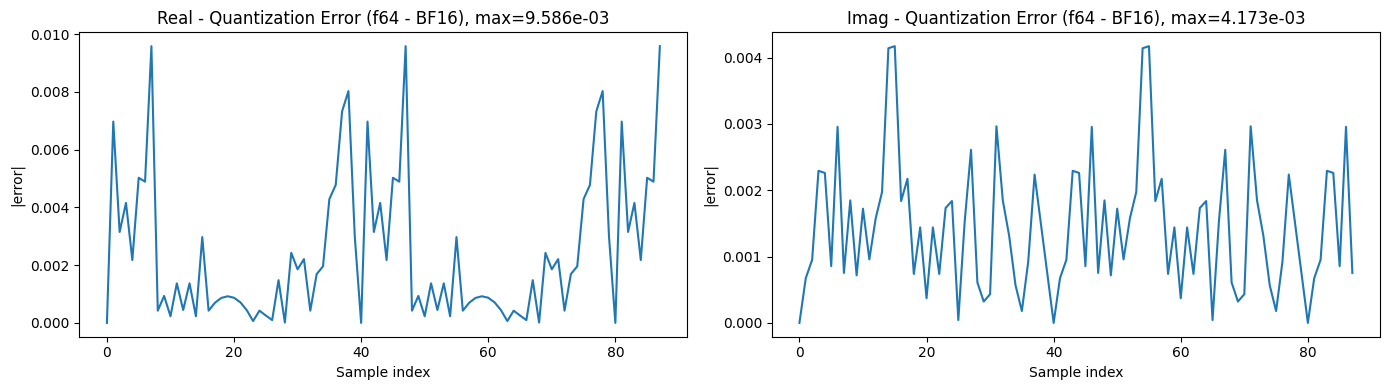

In [8]:
# Cell 8 - Step 4: Quantization Error Analysis (f64 vs BF16)

def farrow_f64(Xm, Xm1, Xm2, mu):
    half_Xm2 = 0.5 * Xm2
    half_Xm  = 0.5 * Xm
    v2 = half_Xm2 - Xm1 + half_Xm
    v1 = -half_Xm2 + 2*Xm1 - 1.5*Xm
    v0 = Xm
    return v0 + mu * (v1 + mu * v2)

f64_real_out, f64_imag_out = [], []
for m in m_range:
    for mu in mu_values:
        f64_real_out.append(farrow_f64(
            x1_at(m).real, x1_at(m+1).real, x1_at(m+2).real, mu))
        f64_imag_out.append(farrow_f64(
            x1_at(m).imag, x1_at(m+1).imag, x1_at(m+2).imag, mu))

f64_real_out = np.array(f64_real_out)
f64_imag_out = np.array(f64_imag_out)

# Quantization error: difference between f64 and BF16 architecture outputs
err_quant_real = np.abs(f64_real_out - arch_real_out)
err_quant_imag = np.abs(f64_imag_out - arch_imag_out)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, err, label in zip(axes, [err_quant_real, err_quant_imag], ['Real', 'Imag']):
    ax.plot(err)
    ax.set_title(f'{label} - Quantization Error (f64 - BF16), max={err.max():.3e}')
    ax.set_xlabel('Sample index')
    ax.set_ylabel('|error|')

plt.tight_layout()
plt.show()


### Step 6 (Generate .dat for RTL Testbench)

In [9]:
# Cell 9 - 產生 RTL Testbench 用的 .dat 檔

def bf16_to_hex(x):
    """BF16 namedtuple → 4-digit uppercase hex string"""
    val = (x.s << 15) | (x.e << 7) | x.f
    return f'{val:04X}'

# 輸入序列：每個 m 只存一行
m_input_range = np.arange(10, 23)  # m = 10..22 (含 2 個暖機)

x1_real_lines = [bf16_to_hex(float_to_bf16(x1_at(m).real)) for m in m_input_range]
x1_imag_lines = [bf16_to_hex(float_to_bf16(x1_at(m).imag)) for m in m_input_range]
mu_lines      = [bf16_to_hex(float_to_bf16(mu)) for mu in mu_values]  # 8 個 μ

# Golden 輸出：88 個 bit-true model 結果
golden_real_lines = [bf16_to_hex(b) for b in arch_real_out_bf16]
golden_imag_lines = [bf16_to_hex(b) for b in arch_imag_out_bf16]

# 寫檔
files = {
    'x1_real_in.dat' : x1_real_lines,
    'x1_imag_in.dat' : x1_imag_lines,
    'mu_in.dat'      : mu_lines,
    'golden_real.dat': golden_real_lines,
    'golden_imag.dat': golden_imag_lines,
}
for fname, lines in files.items():
    path = os.path.join(DAT_DIR, fname)
    with open(path, 'w') as f:
        f.write('\n'.join(lines) + '\n')
    print(f'{fname}: {len(lines)} lines')

# Sanity check 
print(f'\nmu_in[0] = {mu_lines[0]}  (expect 0000)')
print(f'mu_in[1] = {mu_lines[1]}  (expect 3E00, = 1/8)')
print(f'golden_real[0] = {golden_real_lines[0]}  (m=10, mu=0)')

x1_real_in.dat: 13 lines
x1_imag_in.dat: 13 lines
mu_in.dat: 8 lines
golden_real.dat: 88 lines
golden_imag.dat: 88 lines

mu_in[0] = 0000  (expect 0000)
mu_in[1] = 3E00  (expect 3E00, = 1/8)
golden_real[0] = BF80  (m=10, mu=0)


### Step6 (RTL Output vs Golden)

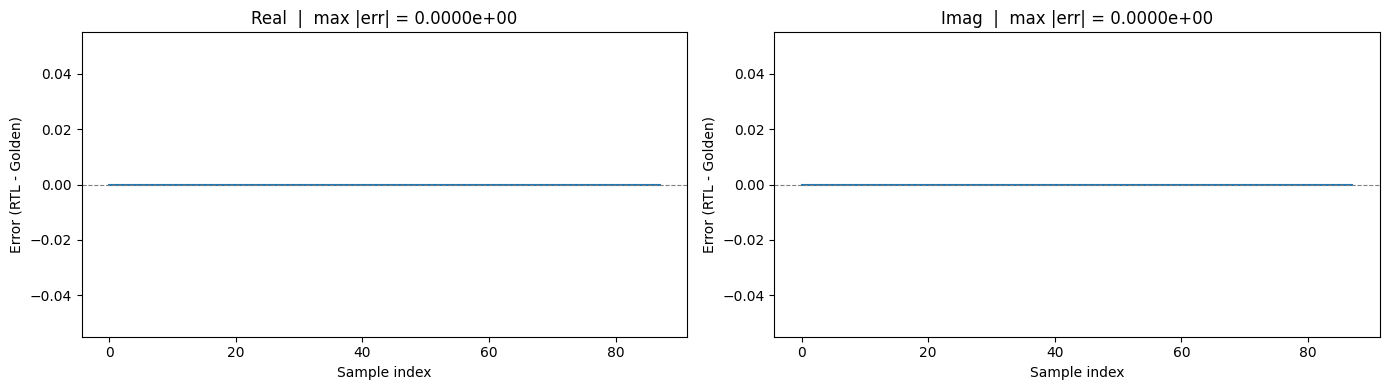

In [10]:
# Cell 10 - RTL Output vs Golden 誤差比較

def hex_to_bf16(h):
    val = int(h.strip(), 16)
    return BF16((val >> 15) & 1, (val >> 7) & 0xFF, val & 0x7F)

def read_dat(fname):
    path = os.path.join(DAT_DIR, fname)
    with open(path) as f:
        return np.array([bf16_to_float(hex_to_bf16(line)) for line in f if line.strip()])

golden_real = read_dat('golden_real.dat')
golden_imag = read_dat('golden_imag.dat')
output_real = read_dat('output_real.dat')
output_imag = read_dat('output_imag.dat')

err_real = output_real - golden_real
err_imag = output_imag - golden_imag

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, err, label in zip(axes, [err_real, err_imag], ['Real', 'Imag']):
    ax.plot(err)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label}  |  max |err| = {np.abs(err).max():.4e}')
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Error (RTL - Golden)')

plt.tight_layout()
plt.show()